In [1]:
# Imports, as always...
import os
import numpy as np
import pandas as pd
from typing import List
from tqdm import tqdm

# Circuitry.
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import random_unitary
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

# Braket.
from qiskit_braket_provider import BraketProvider
from braket.tracking import Tracker
from braket.aws.aws_quantum_task import AwsQuantumTask
from qiskit.visualization import plot_histogram
from qiskit.qasm3 import loads

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Circuit

In [5]:
def ghz_state_circuit(n : int):
    assert n > 1, "Come on now, don't be silly. At least 2 qubits."
    
    # Instantiate a circuit object.
    circuit = QuantumCircuit(n)
    
    # Hadamard.
    circuit.h(0)

    # CNOTs.
    for i in range(1, n):
        circuit.cx(0, i)

    # Measure.
    circuit.measure_all()
    
    return circuit

# Demo.
demo_circuit = ghz_state_circuit(n=5)
demo_circuit.draw()

┌───┐                     ░ ┌─┐            
   q_0: ┤ H ├──■────■────■────■───░─┤M├────────────
        └───┘┌─┴─┐  │    │    │   ░ └╥┘┌─┐         
   q_1: ─────┤ X ├──┼────┼────┼───░──╫─┤M├─────────
             └───┘┌─┴─┐  │    │   ░  ║ └╥┘┌─┐      
   q_2: ──────────┤ X ├──┼────┼───░──╫──╫─┤M├──────
                  └───┘┌─┴─┐  │   ░  ║  ║ └╥┘┌─┐   
   q_3: ───────────────┤ X ├──┼───░──╫──╫──╫─┤M├───
                       └───┘┌─┴─┐ ░  ║  ║  ║ └╥┘┌─┐
   q_4: ────────────────────┤ X ├─░──╫──╫──╫──╫─┤M├
                            └───┘ ░  ║  ║  ║  ║ └╥┘
meas: 5/═════════════════════════════╩══╩══╩══╩══╩═
                                     0  1  2  3  4

# Data Generating

In [7]:
# Device.
# Set region.
# IonQ and QuEra are on us-east-1, IQM is on eu-north-1, and Rigetti is on us-west-1.
os.environ['AWS_REGION'] = 'us-east-1'

# What's online at the moment?
provider = BraketProvider()
#provider.backends(statuses=['ONLINE'])

In [26]:
# Getting a device.
qpu = provider.get_backend('SV1')
print(qpu)

BraketBackend[SV1]


In [29]:
# Generating data.
def time_varied_routine(
    n : int,
    steps: int,
    batch: int,
    device,
    n_shots: int = 128,
    save_path = None,
    verbose: bool = False
) -> pd.DataFrame:
    # Dataframe to hold metadata.
    metadata_df = pd.DataFrame(columns=['n', 'step', 'batch', 'n_shots', 'device', 'task_id'])
    if save_path:
        metadata_df.to_csv(save_path, index=False) # Writing headers.

    # Start tracking costs.
    t = Tracker().start()

    for step in (tqdm(range(1, steps+1), desc='Steps') if verbose else range(1, steps+1)):
        # Build the experiment circuit.
        experiment_circuit = ghz_state_circuit(n)

        # Queue (and run) task.
        qpu_task = device.run(experiment_circuit, shots=n_shots)

        # Store metadata.
        run_metadata_df = pd.DataFrame({
            'n' : [n],
            'step' : [step],
            'batch' : [batch],
            'n_shots' : [n_shots],
            'device' : [device.name],
            'task_id' : [qpu_task.task_id()]
        })

        # Add to the overall results.
        metadata_df = pd.concat([metadata_df, run_metadata_df], ignore_index=True)

        # Save as we go (appending to file).
        if save_path:
            run_metadata_df.to_csv(save_path, mode='a', header=False, index=False)

    # Calculate costs.
    print(f'Total estimated cost: {t.qpu_tasks_cost() + t.simulator_tasks_cost():.3f} USD')

    # Return metadata (results to be collected from AWS using task_id).
    return metadata_df

In [31]:
df = time_varied_routine(n=5, steps=3, batch=1, device=qpu, verbose=True)

Steps: 100%|██████████| 3/3 [00:02<00:00,  1.01it/s]

Total estimated cost: 0.000 USD


In [32]:
df

,n,step,batch,n_shots,device,task_id
0,3,1,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
1,3,2,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
2,3,3,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
3,4,1,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
4,4,2,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
5,4,3,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
6,5,1,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
7,5,2,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...
8,5,3,1,128,SV1,arn:aws:braket:us-east-1:745438739765:quantum-...


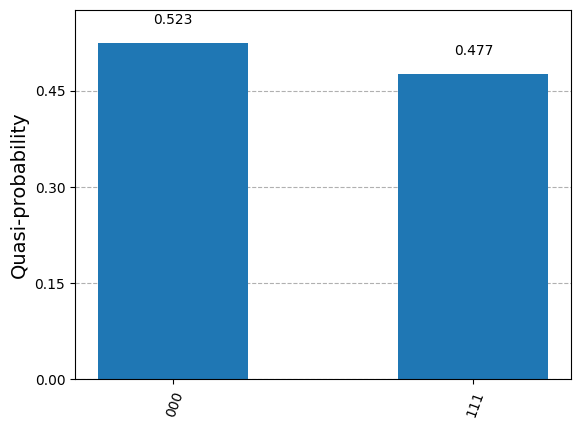

In [33]:
retrieved_task = AwsQuantumTask(arn=df.iloc[0]['task_id'])
plot_histogram(retrieved_task.result().measurement_probabilities)

In [34]:
retrieved_task.result().task_metadata.endedAt

'2025-08-06T01:28:07.256Z'